In [41]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os
import csv
import joblib
import warnings

warnings.filterwarnings('ignore')

tf.random.set_seed(42)
np.random.seed(42)

BASE_PATH_RVES = "./rves"
BASE_PATH_CURVES = "./strain-stress"

N_STRAIN_POINTS = 201
TOTAL_SAMPLES = 67
N_TRAIN = 55
N_TEST = 12
SHAPE = (100, 100, 100)

os.environ['TF_NUM_INTRAOP_THREADS'] = '12'
os.environ['TF_NUM_INTEROP_THREADS'] = '12'

In [42]:
from scipy.interpolate import interp1d

def read_metadata(folder_path):
    meta_path = os.path.join(folder_path, "metadata.csv")
    vol_frac = 0.0
    if not os.path.exists(meta_path): return vol_frac
    with open(meta_path, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            if row.get('parameter') == 'actual_volume_fraction_%':
                try: vol_frac = float(row.get('value', 0))
                except ValueError: pass
                break
    return vol_frac

def read_rve_from_folder(folder_path, shape):
    rve = np.zeros(shape, dtype=np.float32)
    base_name = os.path.basename(folder_path)
    for z in range(shape[2]):
        layer_file = os.path.join(folder_path, f"{base_name}_layer_{z+1}.csv")
        if not os.path.exists(layer_file):
            layer_file = os.path.join(folder_path, f"rve_layer_{z+1}.csv")
        if not os.path.exists(layer_file):
             layer_file = os.path.join(folder_path, f"layer_{z+1}.csv")
        
        if not os.path.exists(layer_file):
            raise FileNotFoundError(f"Слой {z+1} не найден в {folder_path}")
            
        try:
            layer = np.loadtxt(layer_file, delimiter=',', dtype=np.float32)
            if layer.shape == (shape[0], shape[1]):
                rve[:, :, z] = layer
            else:
                with open(layer_file, 'r') as f:
                    reader = csv.reader(f)
                    layer_data = [[float(x) for x in row if x.strip()] for row in reader if len([x for x in row if x.strip()]) == shape[1]]
                    if layer_data: rve[:, :, z] = np.array(layer_data, dtype=np.float32)
        except Exception:
             with open(layer_file, 'r') as f:
                reader = csv.reader(f)
                layer_data = [[float(x) for x in row if x.strip()] for row in reader if len([x for x in row if x.strip()]) == shape[1]]
                if layer_data: rve[:, :, z] = np.array(layer_data, dtype=np.float32)
    return rve

def read_curve(csv_path):
    try: data = np.loadtxt(csv_path, delimiter=',', skiprows=1, encoding='utf-8-sig')
    except: data = np.loadtxt(csv_path, delimiter=';', skiprows=1, encoding='utf-8-sig')
    if data.ndim == 1: data = data.reshape(-1, 2)
    return data[:, 0], data[:, 1]

def resample_curve(strain, stress, target_strain_grid):
    unique_indices = np.unique(strain, return_index=True)[1]
    f = interp1d(strain[unique_indices], stress[unique_indices], kind='linear', 
                 fill_value=(stress[unique_indices][0], stress[unique_indices][-1]), bounds_error=False)
    return np.maximum(f(target_strain_grid), 0)

In [ ]:
from scipy.ndimage import zoom

def preprocess_for_mlp(rve_original, target_shape=(10, 10, 10)):
    rve_min, rve_max = np.min(rve_original), np.max(rve_original)
    rve_norm = (rve_original - rve_min) / (rve_max - rve_min + 1e-8)
    zoom_factors = [t/o for t, o in zip(target_shape, rve_original.shape)]
    rve_small = zoom(rve_norm, zoom_factors, order=1)
    return rve_small.flatten()

def load_data_mlp():
    all_indices = list(range(1, TOTAL_SAMPLES + 1))
    train_indices = all_indices[:N_TRAIN]
    test_indices = all_indices[N_TRAIN:]
    strain_grid = np.linspace(0, 0.15, N_STRAIN_POINTS)
    
    X_train_mlp, X_train_meta, y_train = [], [], []
    for i in train_indices:
        rve_folder = os.path.join(BASE_PATH_RVES, f"rve_csv{i}")
        curve_files = [os.path.join(BASE_PATH_CURVES, f"strain-stress{i}.csv"), os.path.join(BASE_PATH_CURVES, f"strain_stress{i}.csv")]
        curve_file = next((f for f in curve_files if os.path.exists(f)), None)
        if not os.path.isdir(rve_folder) or curve_file is None: continue
        
        try:
            rve_raw = read_rve_from_folder(rve_folder, SHAPE)
            X_train_mlp.append(preprocess_for_mlp(rve_raw))
            X_train_meta.append([read_metadata(rve_folder)])
            y_train.append(resample_curve(*read_curve(curve_file), strain_grid))
        except Exception as e: print(f"Ошибка {i}: {e}")

    X_test_mlp, X_test_meta, y_test = [], [], []
    for i in test_indices:
        rve_folder = os.path.join(BASE_PATH_RVES, f"rve_csv{i}")
        curve_files = [os.path.join(BASE_PATH_CURVES, f"strain-stress{i}.csv"), os.path.join(BASE_PATH_CURVES, f"strain_stress{i}.csv")]
        curve_file = next((f for f in curve_files if os.path.exists(f)), None)
        if not os.path.isdir(rve_folder) or curve_file is None: continue
        
        try:
            rve_raw = read_rve_from_folder(rve_folder, SHAPE)
            X_test_mlp.append(preprocess_for_mlp(rve_raw))
            X_test_meta.append([read_metadata(rve_folder)])
            y_test.append(resample_curve(*read_curve(curve_file), strain_grid))
        except Exception as e: print(f"Ошибка {i}: {e}")
        
    X_train_comb = np.hstack([np.array(X_train_mlp), np.array(X_train_meta)])
    X_test_comb = np.hstack([np.array(X_test_mlp), np.array(X_test_meta)])
    
    print(f"Train: {X_train_rve.shape}, Test: {X_test_rve.shape}")
    return X_train_comb, np.array(y_train), X_test_comb, np.array(y_test), strain_grid

X_train, y_train, X_test, y_test, strain_grid = load_data_mlp()

In [ ]:
class MLP_GPR_Model:
    def __init__(self, input_dim, n_strain_points=201, latent_dim=32, random_state=42):
        self.n_strain_points = n_strain_points
        self.latent_dim = latent_dim
        self.random_state = random_state
        self.scaler_features = StandardScaler() 
        self.scaler_target = StandardScaler()   
        self._build_mlp(input_dim)
        
    def _build_mlp(self, input_dim):
        inputs = layers.Input(shape=(input_dim,), name='mlp_input')
        x = layers.Dense(128, activation='relu')(inputs)
        x = layers.Dropout(0.2)(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dropout(0.2)(x)
        x = layers.Dense(32, activation='relu')(x)
        outputs = layers.Dense(self.latent_dim, activation='linear', name='latent_output')(x)
        self.mlp_extractor = models.Model(inputs=inputs, outputs=outputs)
        
    def train_mlp(self, X_train, y_train, X_val, y_val, epochs=100, batch_size=16, patience=20):
        mlp_output = self.mlp_extractor.output
        head = layers.Dense(128, activation='relu')(mlp_output)
        head = layers.Dense(self.n_strain_points, activation='linear', name='temp_out')(head)
        
        temp_model = models.Model(inputs=self.mlp_extractor.input, outputs=head)
        temp_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
        
        early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True, verbose=1)
        reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
        
        history = temp_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                                 epochs=epochs, batch_size=batch_size,
                                 callbacks=[early_stop, reduce_lr], verbose=1)
        del temp_model
        return history
        
    def extract_latent_features(self, X):
        return self.mlp_extractor.predict(X, verbose=0)
        
    def train_gpr_heads(self, X_train, y_train):
        Z_train = self.extract_latent_features(X_train)
        Z_train_scaled = self.scaler_features.fit_transform(Z_train)
        y_scaled = self.scaler_target.fit_transform(y_train)

        from sklearn.gaussian_process import GaussianProcessRegressor
        from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
        
        self.gpr_models = []
        kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(1e-2)
        
        for i in range(self.n_strain_points):
            gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=2, normalize_y=False, random_state=self.random_state)
            gpr.fit(Z_train_scaled, y_scaled[:, i])
            self.gpr_models.append(gpr)
        
    def predict_with_uncertainty(self, X_new):
        if not hasattr(self.scaler_features, 'mean_'):
            raise RuntimeError("StandardScaler не обучен! Сначала выполните train_gpr_heads().")
            
        Z_new = self.extract_latent_features(X_new)
        Z_new_scaled = self.scaler_features.transform(Z_new)
        
        means, stds = [], []
        for gpr in self.gpr_models:
            m, s = gpr.predict(Z_new_scaled, return_std=True)
            means.append(m); stds.append(s)
            
        mean_curve = self.scaler_target.inverse_transform(np.column_stack(means))
        std_curve = np.column_stack(stds) * self.scaler_target.scale_
        return mean_curve, std_curve
        
    def save(self, path):
        os.makedirs(path, exist_ok=True)
        self.mlp_extractor.save(os.path.join(path, 'mlp_extractor.keras'))
        joblib.dump(self.gpr_models, os.path.join(path, 'gpr_heads.pkl'))
        joblib.dump(self.scaler_features, os.path.join(path, 'scaler_features.pkl'))
        joblib.dump(self.scaler_target, os.path.join(path, 'scaler_target.pkl'))

In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
print(f"Train: {X_tr.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

model_mlp = MLP_GPR_Model(input_dim=X_train.shape[1], latent_dim=32)

Train: (44, 1001), Val: (11, 1001), Test: (12, 1001)


In [ ]:
history_mlp = model_mlp.train_mlp(X_tr, y_tr, X_val, y_val, epochs=100, batch_size=16, patience=20)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 384880.0938 - mae: 579.5391 - val_loss: 376724.0312 - val_mae: 570.9780 - learning_rate: 0.0010
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 384107.0938 - mae: 578.9236 - val_loss: 375403.4688 - val_mae: 569.8989 - learning_rate: 0.0010
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 382325.4062 - mae: 577.4631 - val_loss: 372757.7188 - val_mae: 567.6951 - learning_rate: 0.0010
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 378807.5938 - mae: 574.5513 - val_loss: 367763.2812 - val_mae: 563.4685 - learning_rate: 0.0010
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 372657.7812 - mae: 569.2891 - val_loss: 358888.6250 - val_mae: 555.8307 - learning_rate: 0.0010
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 362482.3125 - mae: 560.5038 - val_loss: 343611.6875 - val_mae: 542.3542 - learning_rate: 0.0010
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 342260.9062 - mae:

In [ ]:
model_mlp.train_gpr_heads(X_train, y_train)

MAE: 17.1169 | RMSE: 24.0876 | R2: 0.9871 | MAPE: 2.92%


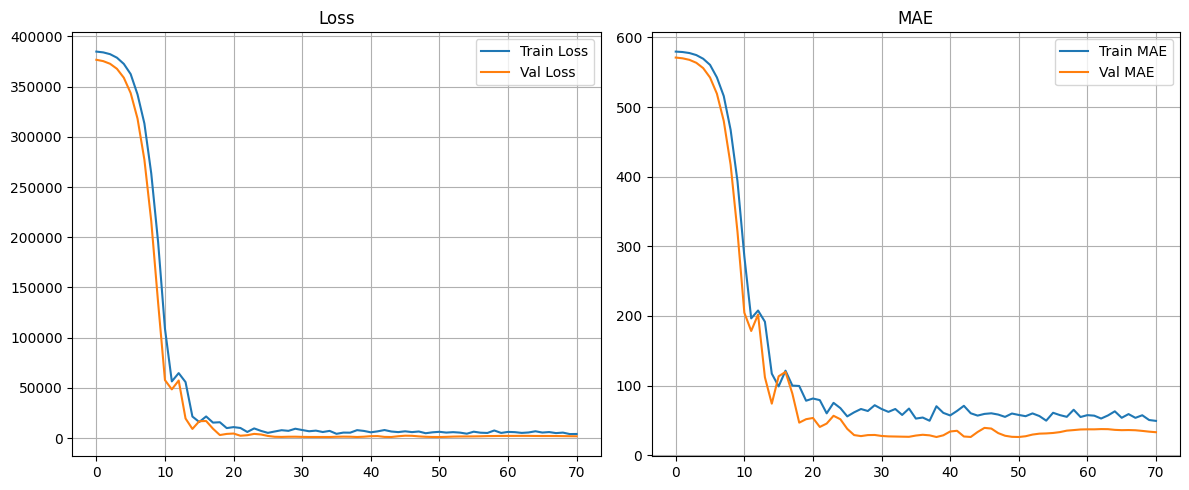

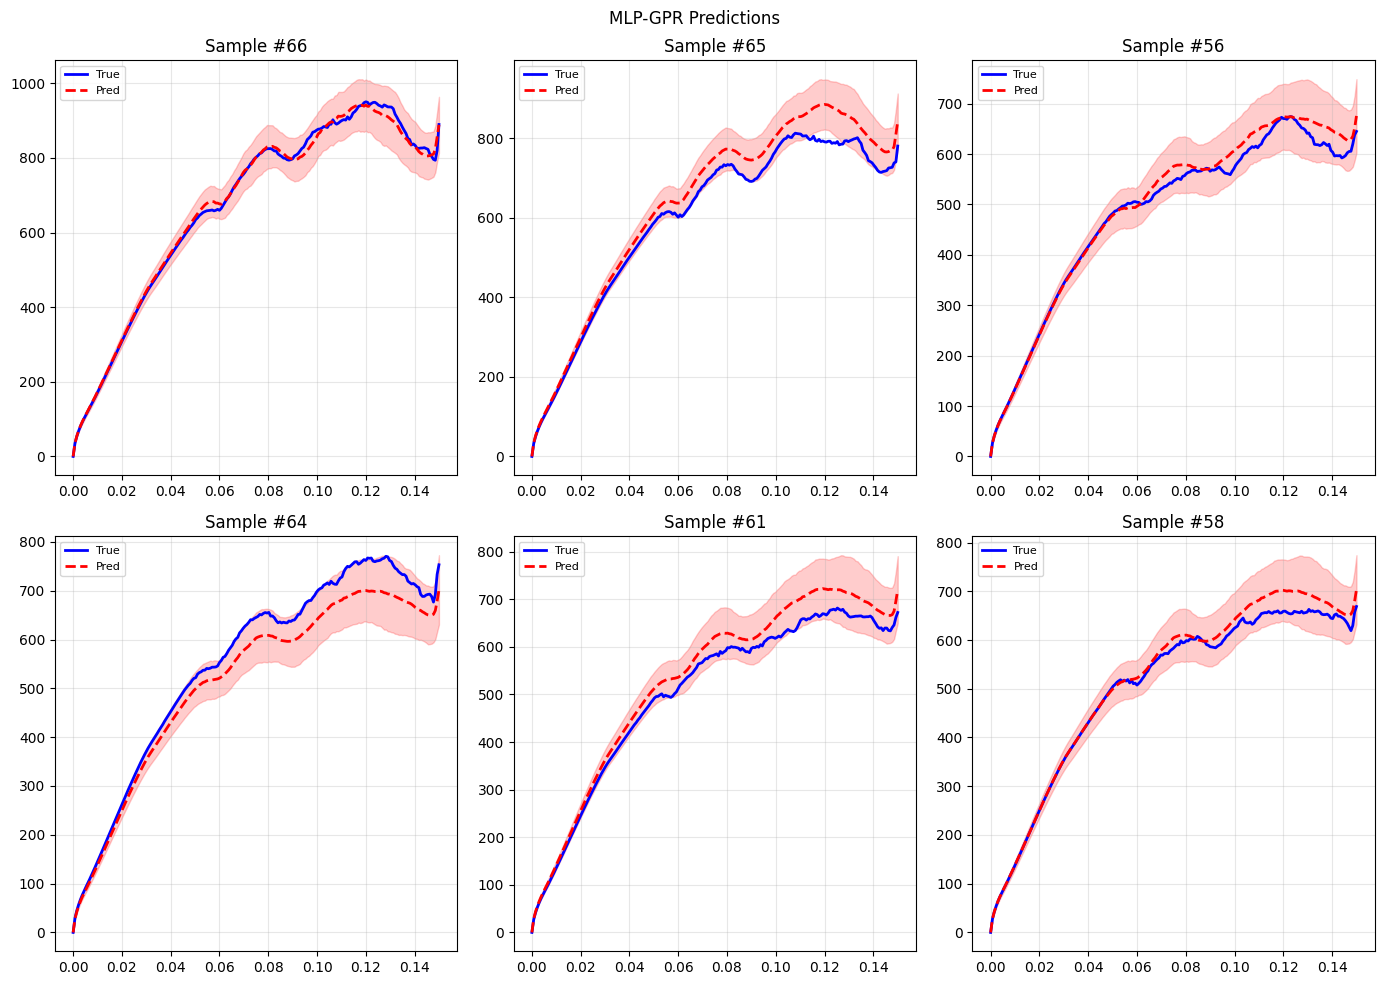

In [ ]:
mean_curve, std_curve = model_mlp.predict_with_uncertainty(X_test)

y_true_flat = y_test.flatten()
y_pred_flat = mean_curve.flatten()
mae = mean_absolute_error(y_true_flat, y_pred_flat)
rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
r2 = r2_score(y_true_flat, y_pred_flat)
mask = y_true_flat != 0
mape = np.mean(np.abs((y_true_flat[mask] - y_pred_flat[mask]) / y_true_flat[mask])) * 100 if np.any(mask) else 0.0

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_mlp.history['loss'], label='Train Loss'); plt.plot(history_mlp.history['val_loss'], label='Val Loss')
plt.title('Loss'); plt.legend(); plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(history_mlp.history['mae'], label='Train MAE'); plt.plot(history_mlp.history['val_mae'], label='Val MAE')
plt.title('MAE'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

all_indices = list(range(1, TOTAL_SAMPLES + 1))
test_indices = all_indices[N_TRAIN:]
n_plots = min(6, len(X_test))
indices = np.random.choice(len(X_test), size=n_plots, replace=False)

plt.figure(figsize=(14, 10))
for i, idx in enumerate(indices):
    plt.subplot(2, 3, i+1)
    plt.plot(strain_grid, y_test[idx], 'b-', lw=2, label='True')
    plt.plot(strain_grid, mean_curve[idx], 'r--', lw=2, label='Pred')
    plt.fill_between(strain_grid, mean_curve[idx]-1.96*std_curve[idx], mean_curve[idx]+1.96*std_curve[idx], color='red', alpha=0.2)
    plt.title(f'Sample #{test_indices[idx]}')
    plt.legend(loc='best', fontsize=8); plt.grid(True, alpha=0.3)
plt.suptitle('MLP-GPR Predictions'); plt.tight_layout(); plt.show()

In [ ]:
model_mlp.save('mlp_gpr')